# 1. Introduction

This notebook aims to create a supervised learning model to predict default on loans in the Lending Club platform.

## **Goal Definition**  

Develop a model to **manage risk proactively after loan issuance** by **predicting default risk before a borrower exhibits clear signs of financial distress** or requires intervention (such as hardship plans or debt settlement). This is particularly relevant in the secondary loan market, where investors purchase already-issued loans and need to assess their ongoing risk. The model’s predictions will be used to evaluate investment strategies, optimize loan selection, and quantify risk exposure by applying default probabilities to open loans. In a real-world scenario, this approach enables early risk detection and facilitates preemptive strategies to minimize defaults, enhance portfolio performance, and maximize returns.

## **Expected Outcomes**

To assess the effectiveness and business implications of the predictive model, we will:
1. **Compare the confusion matrices** of different models to evaluate their classification performance.
2. **Analyze the business impact** of false positives (FP), false negatives (FN), true positives (TP), and true negatives (TN), ensuring that the cost of misclassification is considered.
3. **Modify the decision threshold** to balance cost sensitivity effectively, considering trade-offs between precision and recall.
4. **Determine business implications** of the best-performing model based on confusion matrix results, assessing its practical usability in real-world loan risk management.
5. **Apply the model** trained on “closed” loans (fully paid or defaulted) to “open” loans (ongoing repayments) to estimate **expected business impact**.
6. **Compare different investment strategies** across various credit grades, evaluating profitability based on default rates, interest returns, and risk exposure. The goal is to determine the **optimal strategy to maximize returns while effectively managing risk**.

## Why Predict Default **Post-Issuance** and **Before Hardship or Debt Settlement?**  

The objective is to predict default **after loan issuance** because our dataset contains both open and closed loans, providing real-time information on borrowers who are still repaying. This approach aligns with **risk management in the secondary loan market**, where investors evaluate existing loans rather than deciding whether to approve new ones. By leveraging ongoing loan data, lenders and investors can assess the probability of **financial distress before any intervention,** such as a hardship plan or debt settlement, is implemented.  

Predicting default **after** a hardship plan or debt settlement has been granted would not provide actionable insights, as these interventions already signal that the borrower has encountered financial difficulty. At that stage, the lender's ability to mitigate risk is significantly reduced, making such predictions **less valuable for proactive decision-making**. Moreover, incorporating hardship or debt settlement information into the model would introduce **data leakage**, as these interventions are themselves direct consequences of financial distress. If the model were trained on post-intervention data, it would learn to identify loans as risky simply because a hardship plan exists, rather than truly predicting financial distress in advance. This would **compromise model integrity**, leading to artificially high predictive performance that would not generalize to real-world scenarios where the goal is to intervene **before** a borrower reaches that stage.

# 2. Load Data & Initial Exploration

Import all necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score, recall_score


Load the data and sample from the original data to use a smaller portion of the original dataset to train the model with less computing time and requirements.

In [2]:
df_full = pd.read_csv("Loan_Lending_Club.csv")

/tmp/ipykernel_241553/4292287565.py:1: DtypeWarning: Columns (48,58,117) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv("Loan_Lending_Club.csv")


In [3]:
df = df_full.sample(frac=0.1, random_state=42)

In [4]:
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
958693,222102,10985103,10000.0,10000.0,10000.0,36 months,13.53%,339.50,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1931733,7232,111671970,24550.0,24550.0,24550.0,60 months,15.05%,584.69,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
697955,89776,142513392,20000.0,20000.0,20000.0,60 months,22.35%,556.37,D,D5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
379845,30632,134304036,15000.0,15000.0,15000.0,36 months,11.05%,491.44,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
706759,98580,142301137,12000.0,12000.0,12000.0,36 months,8.46%,378.59,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202995 entries, 958693 to 1399405
Columns: 142 entries, Unnamed: 0 to debt_settlement_flag
dtypes: float64(106), int64(2), object(34)
memory usage: 221.5+ MB


In [6]:
df.describe()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,202995.000000,2.029950e+05,202995.000000,202995.000000,202995.000000,202995.000000,2.029950e+05,202830.000000,202995.000000,202995.000000,...,10824.000000,10824.000000,10824.000000,7281.000000,9437.000000,7281.000000,7281.000000,9174.000000,9437.000000,9437.000000
mean,96537.974822,8.898988e+07,15203.415601,15203.376192,15198.456489,448.644121,7.850696e+04,19.076603,0.314855,698.622232,...,12.435237,0.042683,0.075850,2.319324,143.295235,2.319324,3.609257,280.206290,8842.724064,668.866664
std,90309.115012,3.896495e+07,9292.374785,9292.379889,9290.440463,269.331017,7.394007e+04,14.466430,0.884778,33.210694,...,8.125952,0.390012,0.405625,0.603626,259.682145,0.603626,7.587596,363.477771,7412.946441,1590.716550
min,0.000000,5.716700e+04,1000.000000,1000.000000,725.000000,30.120000,0.000000e+00,-1.000000,0.000000,660.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36058.000000,5.940698e+07,8000.000000,8000.000000,8000.000000,253.040000,4.670000e+04,12.010000,0.000000,675.000000,...,7.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,62.456820,2961.360000,242.290000
50%,72596.000000,9.158458e+07,13000.000000,13000.000000,13000.000000,379.010000,6.500000e+04,18.000000,0.000000,690.000000,...,11.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,174.480000,7084.310000,398.520000
75%,114027.500000,1.258056e+08,20000.000000,20000.000000,20000.000000,598.840000,9.500000e+04,24.817500,0.000000,715.000000,...,16.000000,0.000000,0.000000,2.000000,208.760000,2.000000,0.000000,368.062500,13132.230000,651.720000
max,421093.000000,1.456405e+08,40000.000000,40000.000000,40000.000000,1618.030000,9.500000e+06,999.000000,30.000000,845.000000,...,90.000000,21.000000,15.000000,4.000000,1504.750000,4.000000,38.000000,6847.620000,38390.380000,27337.860000


Initial separation of numerical and categorical column using the `dtype` and exploratoin of these columns.

In [7]:
# Identifying categorical and numerical columns based on the dtype
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Checking unique values for categorical columns to determine type (binary, ordinal, nominal)
categorical_info = {}
for col in categorical_columns:
    unique_values = df[col].nunique()
    sample_values = df[col].dropna().unique()[:5]  # Sample few unique values for assessment
    
    if unique_values == 2:
        category_type = "Binary"
    elif df[col].dtype == 'object' and any(str(val).isdigit() for val in sample_values):
        category_type = "Ordinal"
    else:
        category_type = "Nominal"

    categorical_info[col] = {"Unique Values": unique_values, "Type": category_type, "Sample": sample_values}

df_categorical = pd.DataFrame.from_dict(categorical_info, orient='index')

In [8]:
print(df_categorical)

                           Unique Values     Type  \
term                                   2   Binary   
int_rate                             304  Nominal   
grade                                  7  Nominal   
sub_grade                             35  Nominal   
emp_title                          65343  Nominal   
emp_length                            11  Nominal   
home_ownership                         4  Nominal   
verification_status                    3  Nominal   
issue_d                               60  Nominal   
loan_status                            7  Nominal   
pymnt_plan                             1  Nominal   
url                               202995  Nominal   
purpose                               13  Nominal   
title                                332  Nominal   
zip_code                             886  Nominal   
addr_state                            50  Nominal   
earliest_cr_line                     667  Nominal   
revol_util                          1124  Nomi

In [9]:
print(df[numerical_columns])

         Unnamed: 0         id  loan_amnt  funded_amnt  funded_amnt_inv  \
958693       222102   10985103    10000.0      10000.0          10000.0   
1931733        7232  111671970    24550.0      24550.0          24550.0   
697955        89776  142513392    20000.0      20000.0          20000.0   
379845        30632  134304036    15000.0      15000.0          15000.0   
706759        98580  142301137    12000.0      12000.0          12000.0   
...             ...        ...        ...          ...              ...   
1669929       44873   88064195    15000.0      15000.0          15000.0   
611959         3780  145512306    20000.0      20000.0          20000.0   
1141333      169113   58250198    30000.0      30000.0          30000.0   
840358       103767   22962757    25000.0      25000.0          25000.0   
1399405        6090   75749100    24000.0      24000.0          24000.0   

         installment  annual_inc    dti  delinq_2yrs  fico_range_low  ...  \
958693        339.50  

# 3. Data Cleaning (Before Train-Test Split)

Analyzing the first pre-eliminary exploration of the columns, and looking into what each column expresses we can start doing some feature selection...

Columns that serve as identifiers, have a lot of unique values or have what could be considered "random" values, should be deleted: 

In [10]:
numerical_columns.remove('Unnamed: 0')
numerical_columns.remove("id")
categorical_columns.remove("url")
categorical_columns.remove("title")
categorical_columns.remove("emp_title")
categorical_columns.remove("next_pymnt_d")

Column `grade` is discarded as the information is already available on `sub_grade`

In [11]:
categorical_columns.remove("grade")

Columns `policy_code` and `pymnt_plan` are discarded as they only have one unique value for the entire dataset.

In [12]:
df["policy_code"].value_counts()

policy_code
1.0    202995
Name: count, dtype: int64

In [13]:
df["pymnt_plan"].value_counts()

pymnt_plan
n    202995
Name: count, dtype: int64

In [14]:
numerical_columns.remove("policy_code")
categorical_columns.remove("pymnt_plan")

`zip_code` and `addr_state` are discarded because they could introduce bias to the model as they are related to location.

In [15]:
categorical_columns.remove("zip_code")
categorical_columns.remove("addr_state")

The columns that express information about date should be encoded correctly using `datetime`.

In [16]:
# Lista de columnas de fecha a convertir
date_columns = [
    "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d", "issue_d",
    "hardship_start_date", "payment_plan_start_date"
]

# Convertir columnas de fecha a formato datetime
for col in date_columns:
    if col == "issue_d":
        df[col] = pd.to_datetime(df[col], errors="coerce")
    else:
        df[col] = pd.to_datetime(df[col], format="%b-%Y", errors="coerce")  # Formato esperado: 'Mon-YYYY'

We can observe how some columns expressing percentages were interpreted as categorical features becaseu they are coded as strings. They should be cleaned and moved to the list of numerical columns.

In [17]:
df["revol_util"] = df["revol_util"].str.replace("%","").astype(float) / 100
df["int_rate"] = df["int_rate"].str.replace("%","").astype(float) / 100

categorical_columns.remove("revol_util")
categorical_columns.remove("int_rate")

numerical_columns.append("revol_util")
numerical_columns.append("int_rate")

To make the analysis simpler and considering is probably only gonna add noise, joint lenders loans are removed from the dataset. We remove the rows corresponding to this type of loans and the columns that give information about them.

In [18]:
df = df[df["application_type"] == "Individual"]

joint_info = [
    "annual_inc_joint",
    "dti_joint",
    "verification_status_joint",
    "revol_bal_joint",
    "sec_app_fico_range_low",
    "sec_app_fico_range_high",
    "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths",
    "sec_app_mort_acc",
    "sec_app_open_acc",
    "sec_app_revol_util",
    "sec_app_open_act_il",
    "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med"
]

for col in joint_info:
    if col in categorical_columns:
        categorical_columns.remove(col)
    if col in numerical_columns:
        numerical_columns.remove(col)

Finally, we need to exclude columns that leak information about default after the borrower is already in distress.

The following features directly reveal the loan’s final state and they must be removed.
- `recoveries`: Shows money recovered after charge-off, which is only known post-default.
- `collection_recovery_fee`: Only applies after default, leaks post-risk info.
- `chargeoff_within_12_mths`: Indicates a charge-off, which is already a late-stage default indicator.
- `out_prncp`:
- `out_prncp_inv`:
- `total_rec_prncp`:
- `total_rec_int`:
- 
"out_prncp", "out_prncp_inv", "total_rec_prncp", "total_rec_int",
"total_rec_late_fee", "last_pymnt_amnt"

These features make the model useless for predicting risk before financial distress because they confirm the borrower has already defaulted.

The columns related to hardship plans and debt settlements reflect interventions after a borrower is already struggling. If we keep them, the model will not predict risk, it will just confirm borrowers already in trouble, and we want to predict risk to precisely do these type of interventions.

- `hardship_flag`: Indicates the borrower is already in financial trouble.
- `hardship_status`: Only available after hardship is granted, so it leaks post-risk info.
- `hardship_reason`: Hardship is a result of financial distress, so it does not help with early risk detection.
- `hardship_end_date`: Known only after hardship ends.
- `hardship_type`: leaks the reason for hardship → Only known after financial distress begins.
- `deferral_term` leaks the length of payment relief → Known only after hardship approval.
- `hardship_amount`: Payment reduction only set after hardship approval.
- deferral_term: Indicates payment deferral already in place, meaning distress has started.
- `hardship_dpd`: Reflects delinquency at hardship start, which is already a confirmed risk.
- `hardship_loan_status`: Tells us the loan’s condition after hardship begins, making it non-predictive.
- `hardship_length`: Duration of hardship, which is only available after financial issues arise.
- `orig_projected_additional_accrued_interest`: Only calculated after hardship is applied.
- `hardship_payoff_balance_amount`: Only relevant after hardship is applied.
- `hardship_last_payment_amount`: Reflects payment history after hardship approval.
- `debt_settlement_flag`: Indicates the borrower has settled the debt for less than they owed—this means distress is already known.

If we keep these features, the model will learn that hardship = risk, but we need to detect risk before hardship is granted.

We keep `hardship_start_date` and `payment_plan_start_date` because the will be useful to do feature engineering in the future with other columns that have information about date like `last_pymnt_d` or `last_credit_pull_d`. Given our goal to predict default before any intervention like hardship or payment plan, keeping these two columns could be considered data leakage but I consider these two columns as the date when we are predicting default and analysing if the intervention should be made or not.

In [19]:
columns_to_remove = [
    # Loan Status & Final Outcomes
    "recoveries", "collection_recovery_fee", "chargeoff_within_12_mths",

    # Hardship & Debt Settlement (Post-Risk Indicators)
    "hardship_flag", "hardship_status", "hardship_reason", "hardship_end_date",
    "hardship_amount", "deferral_term", "hardship_dpd", "hardship_loan_status", "hardship_length",
    "orig_projected_additional_accrued_interest", "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "debt_settlement_flag", "hardship_type",

    # added 20250319
    "out_prncp", "out_prncp_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "last_pymnt_amnt"
]


for column in columns_to_remove:
    if column in numerical_columns:
        numerical_columns.remove(column)
    else:
        categorical_columns.remove(column)

Loans (rows) with a `loan_status` equivalent to open (the loans with status "In Grace Period", "Late (16-30 days)", "Late (31-120 days)") should be removed as they do not have a final outcome (default or fully paid), making them unsuitable for training a model that predicts loan default based on completed loans. Including them could introduce label uncertainty, as their true repayment behavior is still unknown.

In [20]:
df["loan_status"].value_counts(normalize=True)

loan_status
Fully Paid            0.625706
Current               0.209772
Charged Off           0.156844
Late (31-120 days)    0.004347
In Grace Period       0.002525
Late (16-30 days)     0.000655
Default               0.000152
Name: proportion, dtype: float64

In [21]:
open_loans = df[df["loan_status"].isin(["Current", "Late (31-120 days)", "In Grace Period", "Late (16-30 days)"])]
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]


We can already create a new one-hot variable for default and delete the `loan_status` column.

In [22]:
df["default_flag"] = df["loan_status"].apply(lambda x: 1 if x in ["Charged Off", "Default"] else 0)
df = df.drop(columns="loan_status")
categorical_columns.remove("loan_status")
categorical_columns.append("default_flag")

# 4. Train-Test Split

Before doing the train-test split, we filter out all the columns that were discarded in the previous steps.

In [23]:
df = df[numerical_columns+categorical_columns]

In [24]:
print(numerical_columns)
print(categorical_columns)

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'total_pymnt', 'total_pymnt_inv', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_act

In [25]:
X = df.drop(columns=["default_flag"])
y = df["default_flag"]

if "default_flag" in categorical_columns:
    categorical_columns.remove("default_flag")
print(categorical_columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

['term', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d', 'application_type', 'hardship_start_date', 'payment_plan_start_date']


In [26]:
y_test.value_counts()

default_flag
0    23892
1     5995
Name: count, dtype: int64

# 5. Feature Engineering & Transformation

To integrate feature engineering and outlier handling seamlessly into a **Scikit-Learn pipeline**, a custom transformer class was implemented. This ensures that transformations are applied consistently across both training and test sets, eliminating **data leakage** and enabling a fully automated preprocessing workflow.

## **Feature Engineering: Creating Six New Features**

Six new features were derived from existing columns to enhance the predictive power of the model:

1. **Elapsed Time Features (Months Since Key Events)**
   - Instead of using raw date columns (`last_pymnt_d`, `last_credit_pull_d`, etc.), the **time elapsed** between key financial events was calculated. This transformation allows the model to understand the relative timing of events (e.g., how long ago a payment was made), which is more informative than an absolute date.
   - Absolute dates (`"Jan-2020"`, `"Dec-2018"`) do not provide meaningful insights alone, but knowing that **the last payment was made 15 months ago** gives clear temporal context about the borrower’s financial behavior.
   - The original **date columns were removed** since they were replaced by these **elapsed time variables**.

2. **FICO Score Averaging**
   - Borrowers are assigned **FICO score ranges** with a **low and high bound** (`fico_range_low`, `fico_range_high`).
   - Instead of treating these as two separate values, their **average** was computed to create a single, more intuitive feature (`fico_avg`).
   - This approach reduces dimensionality, avoids redundant information, and better represents the borrower’s creditworthiness in a single numerical value.

The newly engineered features replaced their respective original columns, ensuring that the dataset remains **lean and informative**, while reducing potential multicollinearity.

In [27]:
# Custom Transformer for Feature Engineering
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.elapsed_time_cols = [
            "months_since_last_pymnt", "months_since_last_credit_pull",
            "months_since_hardship_start", "months_since_payment_plan_start",
            "months_since_credit_pull_hardship", "months_since_credit_pull_payment_plan"
        ]
        self.date_columns = [
            "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d", "issue_d",
            "hardship_start_date", "payment_plan_start_date"
        ]
        self.fico_columns = ["fico_range_low", "fico_range_high"]

    def fit(self, X, y=None):
        return self  # No fitting required, transformation only

    def transform(self, X):
        X = X.copy()

        for col in self.date_columns:
            if not np.issubdtype(X[col].dtype, np.datetime64):
                if col == "issue_d":
                    X[col] = pd.to_datetime(X[col], errors="coerce")
                else:
                    X[col] = pd.to_datetime(X[col], format="%b-%Y", errors="coerce")

        # Create Elapsed Time Features (in months)
        X["months_since_last_pymnt"] = (X["issue_d"] - X["last_pymnt_d"]).dt.days // 30
        X["months_since_last_credit_pull"] = (X["issue_d"] - X["last_credit_pull_d"]).dt.days // 30
        X["months_since_hardship_start"] = (X["last_pymnt_d"] - X["hardship_start_date"]).dt.days // 30
        X["months_since_payment_plan_start"] = (X["last_pymnt_d"] - X["payment_plan_start_date"]).dt.days // 30
        X["months_since_credit_pull_hardship"] = (X["last_credit_pull_d"] - X["hardship_start_date"]).dt.days // 30
        X["months_since_credit_pull_payment_plan"] = (X["last_credit_pull_d"] - X["payment_plan_start_date"]).dt.days // 30

        # Replace negative elapsed times with NaN (handling inconsistencies)
        for col in self.elapsed_time_cols:
            X[col] = X[col].apply(lambda x: x if x >= 0 else np.nan)

        # Create Average FICO Score Feature
        X["fico_avg"] = (X["fico_range_low"] + X["fico_range_high"]) / 2

        # Remove Original Date & FICO Columns
        X.drop(columns=self.date_columns + self.fico_columns, inplace=True)

        return X

## **Outlier Handling with IQR Method**

To mitigate the impact of extreme values that could skew the model, the **Interquartile Range (IQR) method** was applied:
- **Outliers were identified** based on their deviation from the 25th and 75th percentiles.
- Instead of removing data, **outliers were replaced with NaN values**, allowing later imputation strategies to handle them appropriately.
- Implementing outlier detection within the pipeline ensures that **training and test data are processed consistently**.

This transformation strategy not only **enhances model interpretability** but also **ensures robust, reliable predictions** without data leakage.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Definir el número de columnas por fila en la visualización
num_cols = 4  # Número de boxplots por fila
num_rows = math.ceil(len(numerical_columns) / num_cols)  # Calcular cuántas filas se necesitan

# Crear la figura con subgráficos
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()  # Asegurar que los ejes sean iterables

# Generar un boxplot para cada columna
for i, col in enumerate(numerical_columns):
    sns.boxplot(y=df[col], ax=axes[i])  # Crear el boxplot
    axes[i].set_title(col)  # Poner el nombre de la columna en el título
    axes[i].set_xlabel("")  # Quitar etiqueta del eje X para mayor claridad

# Eliminar ejes vacíos si el número de columnas no es múltiplo de num_cols
for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()  # Ajustar diseño para evitar solapamiento
plt.show()


In [29]:
# Custom Transformer for Outlier Handling (IQR Method)
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.5):
        self.threshold = threshold
        self.numerical_columns = None

    def fit(self, X, y=None):
        self.numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()

        for col in self.numerical_columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - self.threshold * IQR
            upper_bound = Q3 + self.threshold * IQR

            # Replace outliers with NaN
            X[col] = X[col].apply(lambda x: x if lower_bound <= x <= upper_bound else np.nan)

        return X

In [30]:
# Remove dropped columns from lists
for col in ["fico_range_low", "fico_range_high"] + [
    "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d", "issue_d",
    "hardship_start_date", "payment_plan_start_date"
]:
    if col in numerical_columns:
        numerical_columns.remove(col)
    elif col in categorical_columns:
        categorical_columns.remove(col)

# 6. Handling Missing Values

## Exploration of missig values

We can create a summary of the percentage of null values in the dataframe to have a quick view and later we can analyze column by column.

In [31]:
null_percentage = (df[numerical_columns+categorical_columns].isnull().sum() / len(df)*100).sort_values(ascending=False)
null_percentage[null_percentage != 0]

mths_since_last_record            82.111955
mths_since_recent_bc_dlq          75.066751
mths_since_last_major_derog       71.678656
mths_since_recent_revol_delinq    65.042995
il_util                           49.497775
mths_since_last_delinq            49.236123
mths_since_rcnt_il                42.952454
all_util                          41.275471
open_il_12m                       41.269448
open_act_il                       41.269448
max_bal_bc                        41.269448
open_il_24m                       41.269448
inq_fi                            41.269448
total_cu_tl                       41.269448
inq_last_12m                      41.269448
open_rv_12m                       41.269448
total_bal_il                      41.269448
open_rv_24m                       41.269448
open_acc_6m                       41.269448
mths_since_recent_inq             10.208452
emp_length                         6.183290
num_tl_120dpd_2m                   4.364439
mo_sin_old_il_acct              

In the following way we assure that when the loan is individual, the columns for joint info are null.

In [32]:
# df_individual_lender = df[df["application_type"] == "Individual"]
# joint_info = [
#     "annual_inc_joint",
#     "dti_joint",
#     "verification_status_joint",
#     "revol_bal_joint",
#     "sec_app_fico_range_low",
#     "sec_app_fico_range_high",
#     "sec_app_earliest_cr_line",
#     "sec_app_inq_last_6mths",
#     "sec_app_mort_acc",
#     "sec_app_open_acc",
#     "sec_app_revol_util",
#     "sec_app_open_act_il",
#     "sec_app_num_rev_accts",
#     "sec_app_chargeoff_within_12_mths",
#     "sec_app_collections_12_mths_ex_med"
# ]

# df_individual_lender[joint_info].isnull().sum()

The columns with null values that include information about months since last occurrence of some event don't include value 0 and it is instead represented by null value.

In [33]:
def value_counts_0(df, column):
    value_counts = df[column].value_counts()
    value_counts_0 = value_counts[(value_counts.index == 0.0) | (value_counts.index == 0)]
    return value_counts_0

print(value_counts_0(df, "mths_since_last_record"))
print(value_counts_0(df, "mths_since_recent_bc_dlq"))
print(value_counts_0(df, "mths_since_last_major_derog"))
print(value_counts_0(df, "mths_since_last_delinq"))

Series([], Name: count, dtype: int64)
mths_since_recent_bc_dlq
0.0    63
Name: count, dtype: int64
mths_since_last_major_derog
0.0    29
Name: count, dtype: int64
mths_since_last_delinq
0.0    144
Name: count, dtype: int64


## Missing values imputation

After an analysis of missing values was conducted, an appropriate imputation strategy was determined based on the nature of the missing data.

The columns *`mths_since_last_record`*, *`mths_since_last_major_derog`*, *`mths_since_recent_bc_dlq`* and *`mths_since_last_delinq`* exhibited a high proportion of missing values (50%-82%), suggesting that missing values likely indicate that the borrower has no history of a recent public record, 90-day or worse rating, or delinquency. Since some of these columns also contained explicit zero values, missing values were imputed with 0 to maintain consistency.

For all other numerical columns with missing values below 50%, the median was used as the imputation strategy to preserve the central tendency of the data without introducing bias.

In [34]:
# Impute "Months Since" Features with 0 (since missing likely means no event occurred)
mths_columns_to_impute = ["mths_since_last_record", "mths_since_last_major_derog", "mths_since_last_delinq", "mths_since_recent_bc_dlq"]

# Impute Other Numerical Features with Median (columns with <50% missing values)
# columns_to_impute_median = [col for col in numerical_columns if col not in joint_info_columns + mths_columns_to_impute]
columns_to_impute_median = [col for col in numerical_columns if col not in mths_columns_to_impute]


# Define the ColumnTransformer with SimpleImputer
missing_value_transformer = ColumnTransformer([
    # ("impute_joint_num", SimpleImputer(strategy="constant", fill_value=0), joint_info_columns),  
    # ("impute_joint_cat", SimpleImputer(strategy="constant", fill_value="Not Joint Lender"), joint_categorical_columns),  
    ("impute_mths", SimpleImputer(strategy="constant", fill_value=0), mths_columns_to_impute),  
    ("impute_median", SimpleImputer(strategy="median"), columns_to_impute_median)  
], remainder="passthrough")  # Keeps all other columns unchanged


# 7. Encoding Categorical Variables

Categorical columns that have an inherent order should be encoded accordingly, preserving their logical sequence with an oridnal encoder. The rest of categorical cloumns will be encoded using one-hot encoder.

In [35]:
df["term"].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [36]:
# Define Ordered Categories for Ordinal Encoding
ordinal_categorical_columns = ["term", "sub_grade", "emp_length"]

term_unique_values = sorted(df["term"].dropna().unique())  # Ensures proper ordering
sub_grade_unique_values = sorted(df["sub_grade"].dropna().unique())  # Ensures logical order
emp_length_categories = ["< 1 year", "1 year", "2 years", "3 years", "4 years", 
                         "5 years", "6 years", "7 years", "8 years", "9 years", "10+ years"]

# Define the OrdinalEncoder with specific category orders
ordinal_encoder = OrdinalEncoder(categories=[term_unique_values, sub_grade_unique_values, emp_length_categories],
                                 handle_unknown="use_encoded_value", unknown_value=-1)

# Define One-Hot Encoding for All Other Categorical Columns
nominal_categorical_columns = list(set(categorical_columns) - set(ordinal_categorical_columns))

onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # Keeps unknown categories from breaking the model

# ColumnTransformer for Categorical Encoding
categorical_transformer = ColumnTransformer([
    ("ordinal", ordinal_encoder, ordinal_categorical_columns),  
    ("onehot", onehot_encoder, nominal_categorical_columns)
], remainder="passthrough")  # Keeps numerical features unchanged


# 8. Scaling Numerical Features

In [37]:
scaler = StandardScaler()

# 9. Feature Selection

In this section, we analyze **multicollinearity** between numerical features to remove redundant information and improve model efficiency. First, we compute the **correlation matrix**, which quantifies the linear relationship between each pair of numerical features. To focus on highly correlated features, we extract only the upper triangle of this matrix, avoiding duplicate values. We then identify **feature pairs with an absolute correlation above 0.8**, as these features provide nearly the same information. Instead of manually assessing which feature to keep from each correlated pair, we take a programmatic approach to ensure a systematic and scalable selection process.

To decide which feature to remove from each correlated pair, we compute **Mutual Information (MI) scores**, which measure the predictive power of each feature concerning the target variable. For each pair of correlated features, we retain the one with the highest MI score, ensuring we keep the most informative feature for predicting default. This automated method is essential because our dataset contains a large number of features, making manual inspection impractical and time-consuming. By integrating this process into a pipeline, we maintain efficiency and consistency, ensuring that feature selection is performed only on the training set to avoid data leakage.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import mutual_info_classif

# Compute Pearson correlation matrix
corr_matrix = df[numerical_columns].corr()

# Plot heatmap (optional)
plt.figure(figsize=(30,30))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.show()

# Filter feature pairs with high correlation (> 0.8)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
high_corr_pairs = (
    corr_matrix.where(mask)
    .stack()
    .reset_index()
    .rename(columns={0: "Correlation"})
    .query("abs(Correlation) > 0.8")
)
high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
high_corr_pairs = high_corr_pairs.sort_values(by="Correlation", ascending=False)
print(high_corr_pairs)

# Compute Mutual Information Scores (MI)
df_temp = df[numerical_columns].copy()
df_temp = df_temp.fillna(df_temp.median())  # Temporary imputation for MI calculation

mi_scores = mutual_info_classif(df_temp, df["default_flag"], random_state=42)
mi_df = pd.DataFrame({"Feature": numerical_columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

# Merge correlation & MI Scores
target_corr = df[numerical_columns+["default_flag"]].corr()["default_flag"].sort_values(ascending=False)
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["Feature", "Correlation"]

mi_corr_df = mi_df.merge(target_corr_df, on="Feature", how="left")
print(mi_corr_df)


The logic for computing correlation between features and MI scores should be enclosed in a new class that will be pipeline-ready.

In [39]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, high_corr_threshold=0.8, mi_threshold=0.005):
        self.high_corr_threshold = high_corr_threshold
        self.mi_threshold = mi_threshold
        self.features_to_remove = []

    def fit(self, X, y=None):
        # Calcula la matriz de correlación
        corr_matrix = X.select_dtypes(include=[np.number]).corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Encuentra pares de características altamente correlacionadas
        high_corr_pairs = [
            (column, upper_tri[column].idxmax())  # Guarda el par con mayor correlación
            for column in upper_tri.columns if any(upper_tri[column] > self.high_corr_threshold)
        ]

        # Calcula MI Scores
        mi_scores = mutual_info_classif(X.fillna(X.median()), y)
        mi_df = pd.DataFrame({"Feature": X.columns, "MI Score": mi_scores}).set_index("Feature")

        # Elegir qué features eliminar (mantener la de mayor MI Score)
        self.features_to_remove = []
        for feature1, feature2 in high_corr_pairs:
            if mi_df.loc[feature1, "MI Score"] >= mi_df.loc[feature2, "MI Score"]:
                self.features_to_remove.append(feature2)
            else:
                self.features_to_remove.append(feature1)

        return self

    def transform(self, X):
        return X.drop(columns=self.features_to_remove, errors="ignore")  


In [40]:
# Add new features added in previous steps to the lists of numerical and categorical columns
numerical_columns.extend([
    "months_since_last_pymnt", "months_since_last_credit_pull",
    "months_since_hardship_start", "months_since_payment_plan_start",
    "months_since_credit_pull_hardship", "months_since_credit_pull_payment_plan",
    "fico_avg"
])

# 10. Model Training

## Pipeline definition

In [41]:
# Create a transformer for numerical imputation: impute mths columns with 0 and the rest with the median.
num_imputer = ColumnTransformer([
    ("impute_mths", SimpleImputer(strategy="constant", fill_value=0), mths_columns_to_impute),
    ("impute_other", SimpleImputer(strategy="median"), list(set(numerical_columns) - set(mths_columns_to_impute)))
])

num_pipeline = Pipeline([
    ("impute", num_imputer),
    ("scaler", StandardScaler())
])

# For categorical data, impute missing values and then apply encoding.
cat_imputer_encoder = Pipeline([
    ("impute_cat", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encode", categorical_transformer)  # This applies your Ordinal and One-Hot encoding.
])

# Main preprocessor to treat numerical and categorical columns separately.
preprocessor = Pipeline([
    ("feature_engineering", FeatureEngineeringTransformer()),
    ("outlier_handling", OutlierHandler(threshold=1.5)),
    ("col_transformer", ColumnTransformer([
         ("num_pipeline", num_pipeline, numerical_columns),
         ("cat_pipeline", cat_imputer_encoder, categorical_columns)
    ], remainder="drop"))
])

# Define Final Pipeline with Model
model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", FeatureSelector(high_corr_threshold=0.8, mi_threshold=0.005)),
    ("classifier", LogisticRegression())
])


## Grid search

In [42]:
# Define Parameter Grid
param_grid = [
    {
        "classifier": [LogisticRegression(max_iter=500)],
        "classifier__C": [0.1, 1.0, 10],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "classifier": [RandomForestClassifier()],
        "classifier__n_estimators": [200, 250],
        "classifier__max_depth": [10, 20, 30],  
        "classifier__min_samples_split": [5, 10, 15],
        "classifier__min_samples_leaf": [5, 10, 15],  
    }
]

# Run the Grid Search
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5, 
    n_jobs=6,
    verbose=4
)

The following cell was executed to execute the training with the grid search and the best model obstained was saved using `joblib`. The training process lasted 2h 10 mins.

In [43]:
# grid_search.fit(X_train, y_train)

# # Export the Best Model and save the model to a file
# best_model = grid_search.best_estimator_

# joblib.dump(best_model, "grid_search_best_model.pkl")
# print("Best model saved as 'best_model.pkl'")

# # Convert Grid Search results to DataFrame
# results_df = pd.DataFrame(grid_search.cv_results_)
# param_columns = [col for col in results_df.columns if col.startswith("param_")]
# results_df = results_df[
#     param_columns + ["mean_test_score", "rank_test_score"]
# ]
# results_df = results_df.sort_values(by="mean_test_score", ascending=False)

# # Display the DataFrame and save it
# results_df.to_csv("grid_search_results.csv")
# print("Grid search results saved as 'grid_search_results.csv'")

In [44]:
model_path = "grid_search_best_model.pkl"
best_model = joblib.load(model_path)

# Predict on test set
y_pred = best_model.predict(X_test)

# Print the saved results from the grid seach
grid_search_results = pd.read_csv("grid_search_results.csv")
grid_search_results.head()

,Unnamed: 0,param_classifier,param_classifier__C,param_classifier__class_weight,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__min_samples_split,param_classifier__n_estimators,mean_test_score,rank_test_score
0,47,RandomForestClassifier(),NaN,NaN,30.0,5.0,15.0,250.0,0.881343,1
1,27,RandomForestClassifier(),NaN,NaN,20.0,5.0,10.0,250.0,0.871930,2
2,45,RandomForestClassifier(),NaN,NaN,30.0,5.0,10.0,250.0,0.871026,3
3,26,RandomForestClassifier(),NaN,NaN,20.0,5.0,10.0,200.0,0.869906,4
4,33,RandomForestClassifier(),NaN,NaN,20.0,10.0,10.0,250.0,0.868143,5


In [45]:
def plot_confusion_matrix_fancy(y_true, y_pred, labels=None, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)']
    group_counts = [f"{value}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

    box_labels = [f"{name}\nCount: {count}\n{percent}" for name, count, percent in zip(group_names, group_counts, group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cm.shape)

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm, annot=box_labels, fmt='', cmap='Blues', cbar=True, linewidths=2, linecolor='black',
                     xticklabels=labels if labels else ['Predicted Negative', 'Predicted Positive'],
                     yticklabels=labels if labels else ['Actual Negative', 'Actual Positive'],
                     annot_kws={"size": 12})
    
    plt.xlabel('Prediction', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(title, fontsize=14)

    # Add color legend
    cbar = ax.collections[0].colorbar
    cbar.set_label('Intensity')

    plt.tight_layout()
    plt.show()

Confusion Matrix:
 [[23683   209]
 [ 1341  4654]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     23892
           1       0.96      0.78      0.86      5995

    accuracy                           0.95     29887
   macro avg       0.95      0.88      0.91     29887
weighted avg       0.95      0.95      0.95     29887



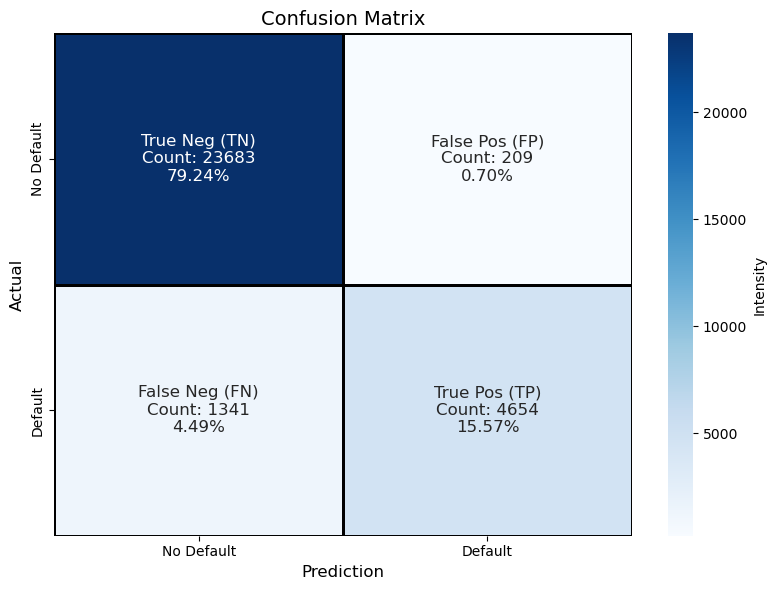

In [46]:
# Print evaluation results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
plot_confusion_matrix_fancy(y_test, y_pred, labels=['No Default', 'Default'])

## Threshold tradeoff

Threshold: 0.1
Confusion Matrix:
 [[19554  4338]
 [   68  5927]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.82      0.90     23892
           1       0.58      0.99      0.73      5995

    accuracy                           0.85     29887
   macro avg       0.79      0.90      0.81     29887
weighted avg       0.91      0.85      0.86     29887



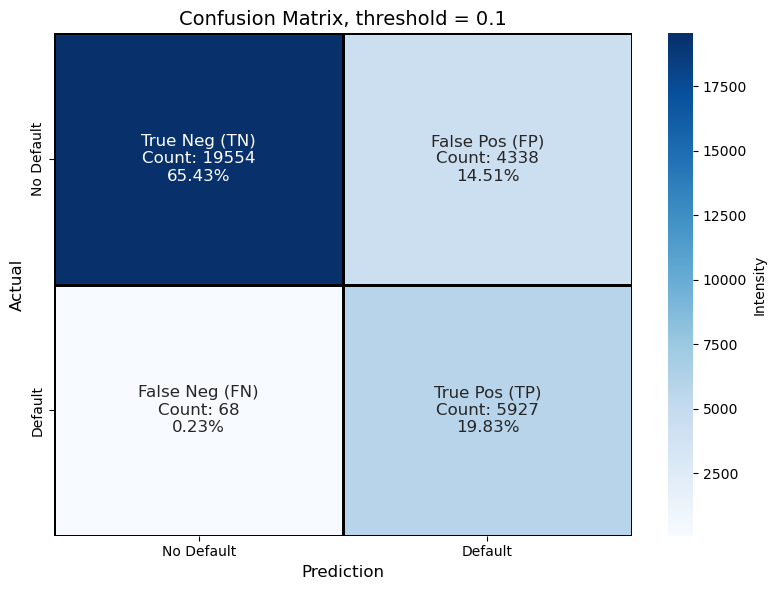

--------------------------------------------------------------------------------
Threshold: 0.2
Confusion Matrix:
 [[21443  2449]
 [  250  5745]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     23892
           1       0.70      0.96      0.81      5995

    accuracy                           0.91     29887
   macro avg       0.84      0.93      0.88     29887
weighted avg       0.93      0.91      0.91     29887



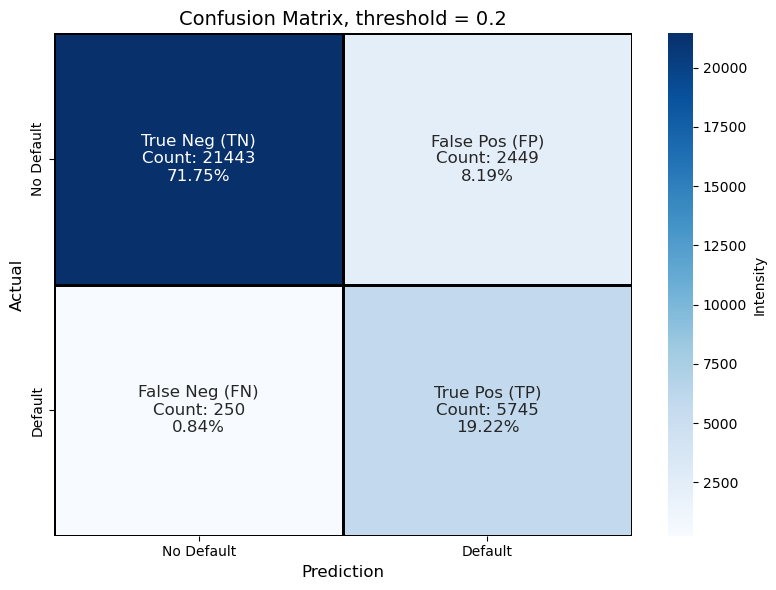

--------------------------------------------------------------------------------
Threshold: 0.30000000000000004
Confusion Matrix:
 [[22221  1671]
 [  409  5586]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.96     23892
           1       0.77      0.93      0.84      5995

    accuracy                           0.93     29887
   macro avg       0.88      0.93      0.90     29887
weighted avg       0.94      0.93      0.93     29887



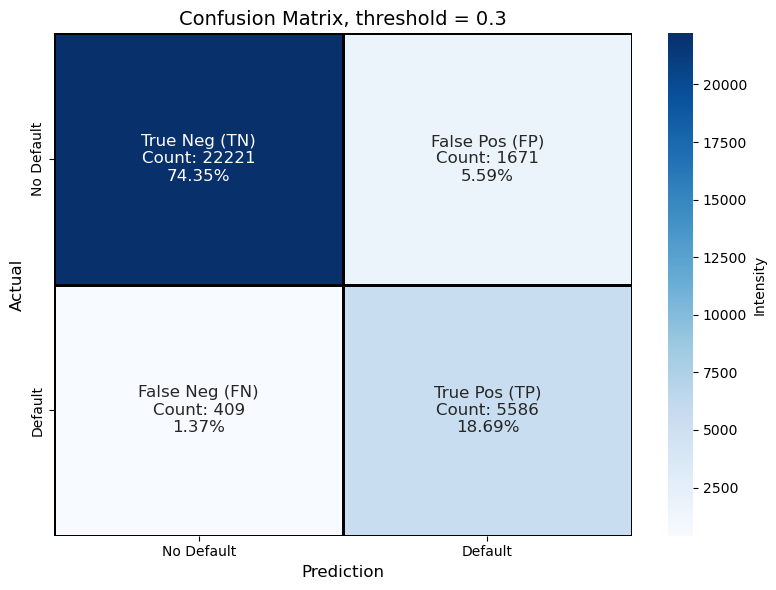

--------------------------------------------------------------------------------
Threshold: 0.4
Confusion Matrix:
 [[23084   808]
 [  718  5277]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     23892
           1       0.87      0.88      0.87      5995

    accuracy                           0.95     29887
   macro avg       0.92      0.92      0.92     29887
weighted avg       0.95      0.95      0.95     29887



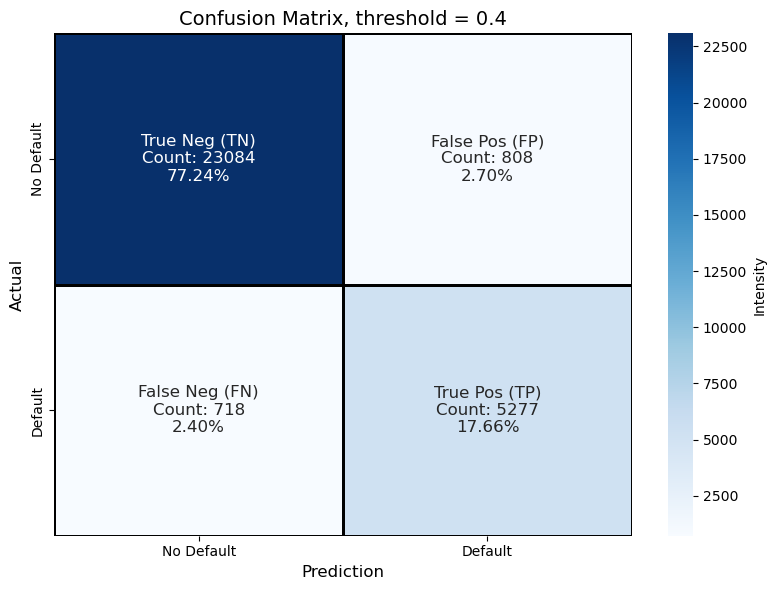

--------------------------------------------------------------------------------
Threshold: 0.5
Confusion Matrix:
 [[23683   209]
 [ 1341  4654]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     23892
           1       0.96      0.78      0.86      5995

    accuracy                           0.95     29887
   macro avg       0.95      0.88      0.91     29887
weighted avg       0.95      0.95      0.95     29887



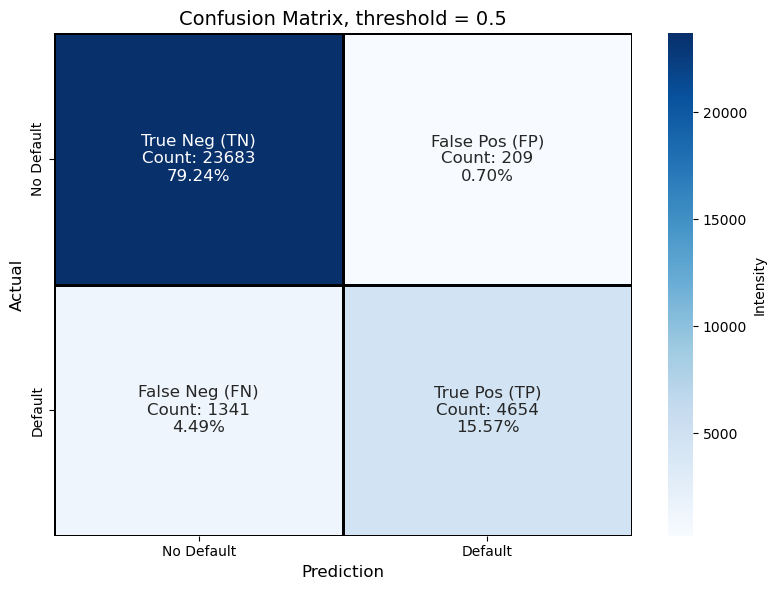

--------------------------------------------------------------------------------
Threshold: 0.6
Confusion Matrix:
 [[23877    15]
 [ 2247  3748]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     23892
           1       1.00      0.63      0.77      5995

    accuracy                           0.92     29887
   macro avg       0.96      0.81      0.86     29887
weighted avg       0.93      0.92      0.92     29887



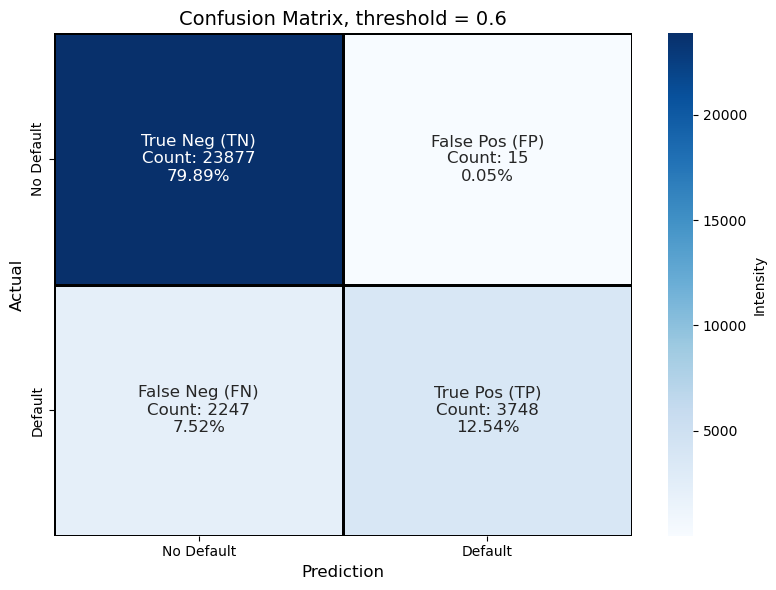

--------------------------------------------------------------------------------
Threshold: 0.7000000000000001
Confusion Matrix:
 [[23891     1]
 [ 3337  2658]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     23892
           1       1.00      0.44      0.61      5995

    accuracy                           0.89     29887
   macro avg       0.94      0.72      0.77     29887
weighted avg       0.90      0.89      0.87     29887



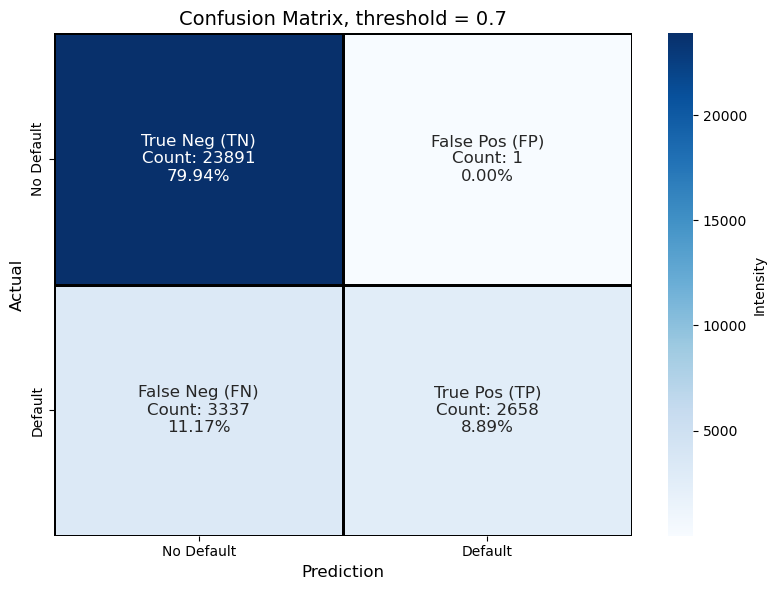

--------------------------------------------------------------------------------
Threshold: 0.8
Confusion Matrix:
 [[23892     0]
 [ 4494  1501]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     23892
           1       1.00      0.25      0.40      5995

    accuracy                           0.85     29887
   macro avg       0.92      0.63      0.66     29887
weighted avg       0.87      0.85      0.81     29887



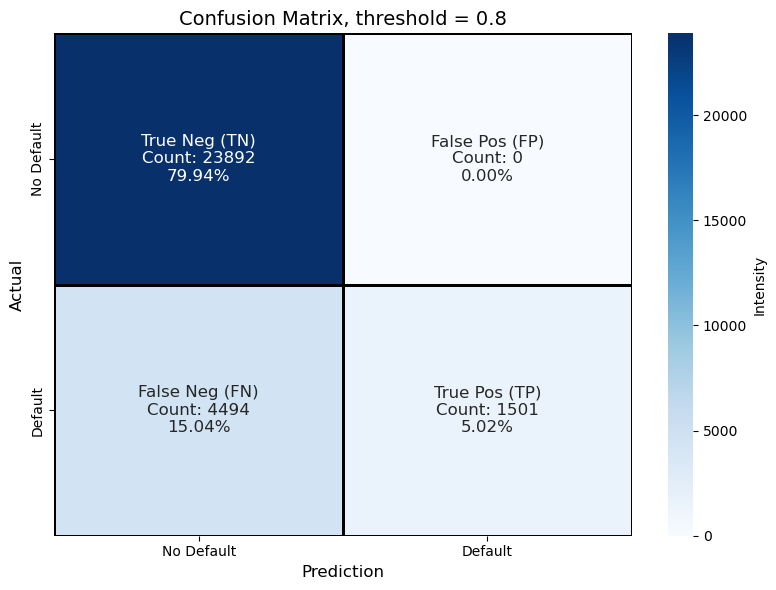

--------------------------------------------------------------------------------
Threshold: 0.9
Confusion Matrix:
 [[23892     0]
 [ 5907    88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     23892
           1       1.00      0.01      0.03      5995

    accuracy                           0.80     29887
   macro avg       0.90      0.51      0.46     29887
weighted avg       0.84      0.80      0.72     29887



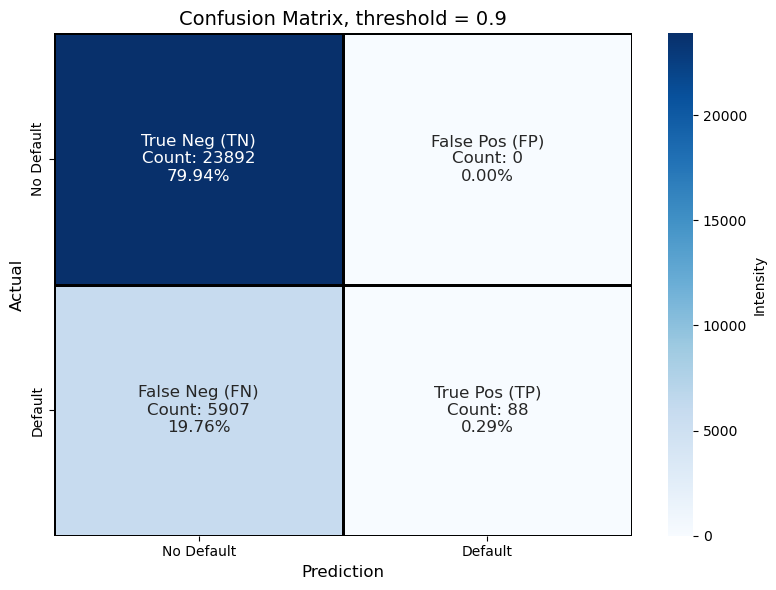

--------------------------------------------------------------------------------
Summary of threshold and key metrics
   Threshold  F1 Score    Recall
3        0.4  0.873675  0.880234
4        0.5  0.857248  0.776314
2        0.3  0.843043  0.931776
1        0.2  0.809782  0.958299
5        0.6  0.768190  0.625188
0        0.1  0.729028  0.988657
6        0.7  0.614282  0.443369
7        0.8  0.400480  0.250375
8        0.9  0.028933  0.014679


In [47]:
# Get Prediction Probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]  # Get probabilities for positive class (default)

# Test Multiple Thresholds
thresholds = np.linspace(0.1, 0.9, 9)  # Test thresholds from 0.1 to 0.9
results = []

for threshold in thresholds:
    print(f"Threshold: {threshold}")
    y_pred_adjusted = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_adjusted)
    recall = recall_score(y_test, y_pred_adjusted)
    results.append({"Threshold": threshold, "F1 Score": f1, "Recall": recall})
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted))
    plot_confusion_matrix_fancy(y_test, y_pred_adjusted, labels=['No Default', 'Default'], title=f"Confusion Matrix, threshold = {round(threshold,1)}")
    print("--------------------------------------------------------------------------------")

# Convert results to a DataFrame
print("Summary of threshold and key metrics")
results_df = pd.DataFrame(results)

# Sort by best F1-score
results_df = results_df.sort_values(by="F1 Score", ascending=False)

# Display results
print(results_df)

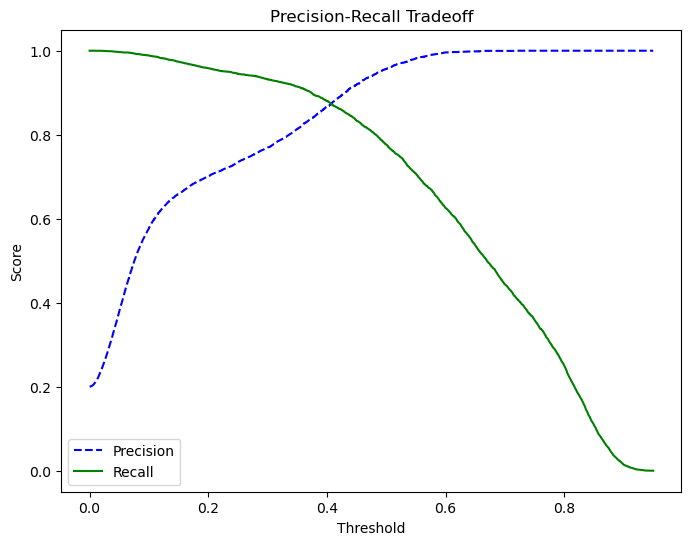

In [48]:
# Plot Precision-Recall Curve
precisions, recalls, threshold_vals = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(threshold_vals, precisions[:-1], "b--", label="Precision")
plt.plot(threshold_vals, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.show()

# 11. Assess investment strategies

In [49]:
# Load and Prepare Open Loans Data
# Apply Preprocessing Pipeline
# The model pipeline includes preprocessing, so we apply `predict_proba` directly
y_prob = best_model.predict_proba(open_loans)[:, 1]  # Get probability of default

# Set the classification threshold
custom_threshold = 0.3
y_pred = (y_prob >= custom_threshold).astype(int)

# Add predictions and probabilities to the open loans dataframe
open_loans_predictions = open_loans.copy()  # Keep original features
open_loans_predictions["default_probability"] = y_prob
open_loans_predictions["default_prediction"] = y_pred

# Save Predictions for backup
predictions_filename = "open_loans_predictions.csv"
open_loans_predictions.to_csv(predictions_filename, index=False)
print(f"Predictions saved as '{predictions_filename}'")

Predictions saved as 'open_loans_predictions.csv'


### Monte Carlo Simulation: Methodology and Key Features

The Monte Carlo simulation is employed to model investment outcomes in Lending Club's secondary market, allowing for an assessment of various investment strategies under uncertainty. The simulation runs **10,000 iterations**, each time constructing a **randomized portfolio** of loans according to predefined investment strategies—Conservative, Balanced, and Aggressive—based on credit grades.

Each loan within the portfolio is **evaluated probabilistically** for default based on model-predicted default probabilities. If a loan defaults, **a portion of the principal is recovered** using historical recovery rates from closed loans. If the loan is fully paid, **discounted cash flow (DCF) analysis** is applied to compute the present value of future installment payments. The simulation further incorporates **risk-adjusted discount rates**, where higher-risk loans are penalized with a greater discounting factor.

The model tracks **total interest earned, total losses from defaults, and net return** across all simulated portfolios. Finally, key performance metrics, including **mean return, worst-case and best-case percentiles, standard deviation, and Sharpe ratio**, are computed to compare strategies.

In [50]:
# Resample closed loans dataset to compute data for recoveries
# It is necessary to resample again because recoveries was deleted previously
df = df_full.sample(frac=0.1, random_state=42)
closed_loans = df[df["loan_amnt"].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()  # Dataset containing closed loans
# Load open loans
open_loans = open_loans_predictions.copy()  # Dataset containing open loans

In [51]:
# Ensure term is properly formatted
open_loans["term"] = open_loans["term"].str.strip().str.split().str[0].astype(int)

# Convert issue date and last payment date to datetime
open_loans["issue_d"] = pd.to_datetime(open_loans["issue_d"], format="%b-%Y")  # Example: "Jan-2019"
open_loans["last_pymnt_d"] = pd.to_datetime(open_loans["last_pymnt_d"], format="%b-%Y")  # Example: "Mar-2021"

# Compute months passed since loan issuance
open_loans["months_passed"] = (open_loans["last_pymnt_d"].dt.year - open_loans["issue_d"].dt.year) * 12 + \
                              (open_loans["last_pymnt_d"].dt.month - open_loans["issue_d"].dt.month)

# Compute remaining term
open_loans["remaining_term"] = open_loans["term"] - open_loans["months_passed"]

# Ensure we don't have negative remaining terms
open_loans["remaining_term"] = open_loans["remaining_term"].clip(lower=0)


Running Monte Carlo simulation for strategy: Conservative...
  Simulation 0/10000...
  Simulation 1000/10000...
  Simulation 2000/10000...
  Simulation 3000/10000...
  Simulation 4000/10000...
  Simulation 5000/10000...
  Simulation 6000/10000...
  Simulation 7000/10000...
  Simulation 8000/10000...
  Simulation 9000/10000...
Monte Carlo simulation completed for Conservative.


Running Monte Carlo simulation for strategy: Balanced...
  Simulation 0/10000...
  Simulation 1000/10000...
  Simulation 2000/10000...
  Simulation 3000/10000...
  Simulation 4000/10000...
  Simulation 5000/10000...
  Simulation 6000/10000...
  Simulation 7000/10000...
  Simulation 8000/10000...
  Simulation 9000/10000...
Monte Carlo simulation completed for Balanced.


Running Monte Carlo simulation for strategy: Aggressive...
  Simulation 0/10000...
  Simulation 1000/10000...
  Simulation 2000/10000...
  Simulation 3000/10000...
  Simulation 4000/10000...
  Simulation 5000/10000...
  Simulation 6000/10000...


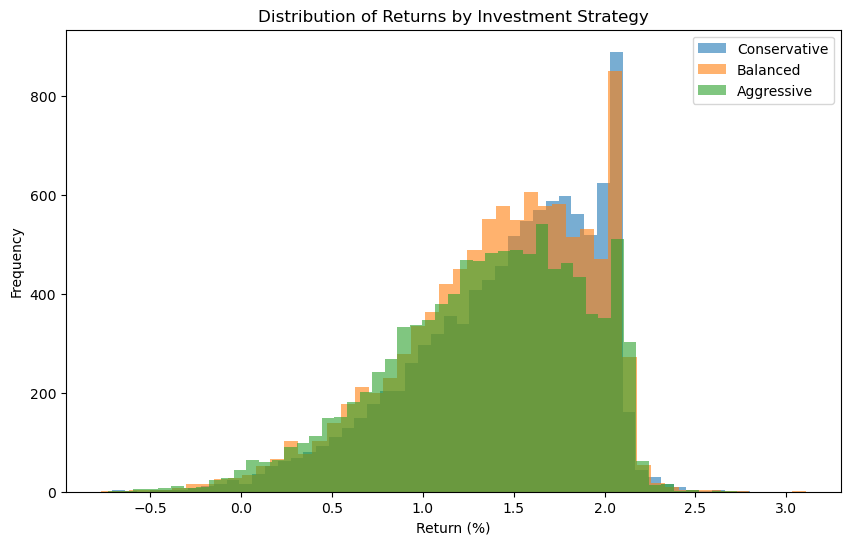

In [52]:
# Set simulation parameters
N_SIMULATIONS = 10000  # Number of Monte Carlo runs
PORTFOLIO_SIZE = 10  # Number of loans per portfolio

# Define investment strategies based on credit grade
STRATEGIES = {
    "Conservative": ["A", "B"],
    "Balanced": ["B", "C", "D"],
    "Aggressive": ["D", "E", "F"]
}

# Compute Recovery Rate from Closed Loans
closed_loans["recovery_rate"] = (closed_loans["recoveries"] - closed_loans["collection_recovery_fee"]) / closed_loans["out_prncp_inv"]
closed_loans["recovery_rate"] = closed_loans["recovery_rate"].clip(lower=0, upper=1)

# Aggregate Average Recovery Rate by Credit Grade
recovery_rates = closed_loans.groupby('grade')['recovery_rate'].mean().to_dict()

# Apply Estimated Recovery Rates to Open Loans
open_loans["estimated_recovery_rate"] = open_loans["grade"].map(recovery_rates)

# Function to compute discounted cash flow (DCF) for a loan
def discounted_cash_flow(cash_flows, discount_rate):
    """Applies discounting to future cash flows."""
    return sum(cash / ((1 + discount_rate) ** t) for t, cash in enumerate(cash_flows, start=1))

# Monte Carlo Simulation Function
def monte_carlo_simulation(strategy, n_simulations, portfolio_size):
    """Simulates investment returns under a given strategy using Monte Carlo."""
    print(f"\nRunning Monte Carlo simulation for strategy: {strategy}...")

    strategy_df = open_loans[open_loans["grade"].isin(STRATEGIES[strategy])].copy()
    
    results = []
    total_interest_earned_list = []
    total_losses_from_defaults_list = []

    for sim in range(n_simulations):
        if sim % (n_simulations // 10) == 0:
            print(f"  Simulation {sim}/{n_simulations}...")

        # Randomly select loans for the portfolio
        portfolio = strategy_df.sample(n=portfolio_size, replace=True)

        total_cash_flows = []
        total_invested = 0
        total_interest_earned = 0
        total_losses_from_defaults = 0

        for _, loan in portfolio.iterrows():
            principal = loan["out_prncp_inv"]
            term = int(loan["remaining_term"])  # Convert '36 months' to 36
            default_prob = loan["default_probability"]
            recovery_rate = loan["estimated_recovery_rate"] if not pd.isna(loan["estimated_recovery_rate"]) else 0  

            # Set base risk-free rate (adjusted for risk)
            risk_free_rate = 0.03 / 12
            risk_premium = {
                "A": 0.005 / 12, "B": 0.015 / 12, "C": 0.035 / 12,
                "D": 0.07 / 12, "E": 0.10 / 12, "F": 0.15 / 12
            }
            discount_rate = risk_free_rate + risk_premium.get(loan["grade"], 0.05 / 12)

            # Simulate whether the loan defaults
            if np.random.binomial(1, default_prob) == 1:  
                recovered_amount = principal * recovery_rate
                net_loss = principal - recovered_amount  
                total_cash_flows.append(-net_loss)  
                total_losses_from_defaults += net_loss  
            else:
                # Loan is fully paid
                cash_flows = [loan["installment"]] * term  
                dcf = discounted_cash_flow(cash_flows, discount_rate)  
                total_cash_flows.append(dcf + principal)  

                # Compute interest earned
                total_interest_earned += (loan["installment"] * term) - principal  

            # Track total investment
            total_invested += principal

        # Compute net return
        net_return = sum(total_cash_flows) / total_invested  
        results.append(net_return)  

        # Append additional metrics
        total_interest_earned_list.append(total_interest_earned)
        total_losses_from_defaults_list.append(total_losses_from_defaults)

    print(f"Monte Carlo simulation completed for {strategy}.\n")

    return np.array(results), np.array(total_interest_earned_list), np.array(total_losses_from_defaults_list)

# Run simulations for each strategy
simulation_results = {}
interest_results = {}
losses_results = {}

for strategy in STRATEGIES.keys():
    sim_result, interest_result, losses_result = monte_carlo_simulation(strategy, N_SIMULATIONS, PORTFOLIO_SIZE)
    simulation_results[strategy] = sim_result
    interest_results[strategy] = interest_result
    losses_results[strategy] = losses_result

# Analyze results
summary_stats = {}

for strategy in STRATEGIES.keys():
    results = simulation_results[strategy]
    interest = interest_results[strategy]
    losses = losses_results[strategy]

    summary_stats[strategy] = {
        "Mean Return": np.mean(results),
        "5th Percentile (Worst Case)": np.percentile(results, 5),
        "95th Percentile (Best Case)": np.percentile(results, 95),
        "Total Interest Earned": np.mean(interest),
        "Total Losses from Defaults": np.mean(losses),
        "Standard Deviation": np.std(results),
        "Sharpe Ratio": np.mean(results) / np.std(results)  
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(summary_stats).T
print("\nMonte Carlo Simulation Summary Statistics:")
print(results_df)

# Plot the distributions of returns for each strategy
plt.figure(figsize=(10, 6))
for strategy, results in simulation_results.items():
    plt.hist(results, bins=50, alpha=0.6, label=strategy)
plt.title("Distribution of Returns by Investment Strategy")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
